# NEW SYSTEM

event, emission, combined_state_transition, realizable combined_state_transition

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### Setup the fluorophores

In [2]:
fluorophores = fl.construct_fluorophores('cy5', 10, 3)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

array([[<AxesSubplot:xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object)

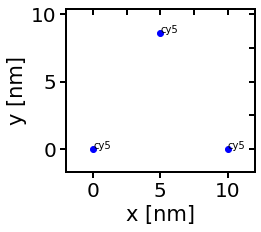

In [3]:
fluorophore_system.plot()

### Setup the transitions

In [4]:
transitions = tr.load_transitions(fluorophore_system, 2.5, 540)

In [5]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [6]:
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'CFRET', 'OFRET', 'TFRET'])

In [7]:
transition_set.adjust_rates({'HFRET(42.4)': 5e5})

In [8]:
transition_set.finalize()

<AxesSubplot:>

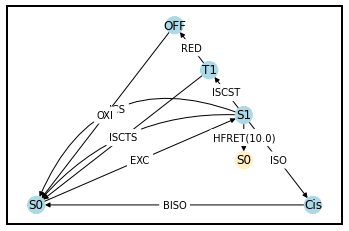

In [9]:
transition_set.plot(graph_type='planar')

### Prediction

In [18]:
prediction = st.Prediction(transition_set)

array([[<AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>]], dtype=object)

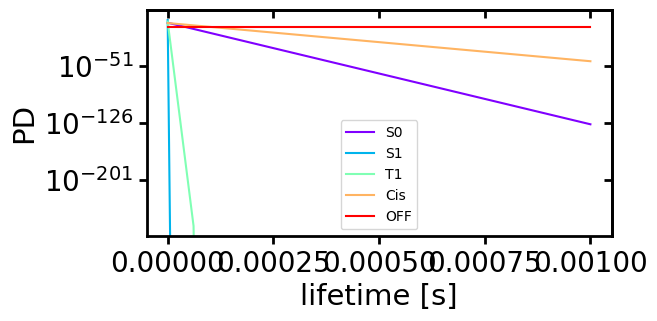

In [19]:
prediction.plot(mode='lifetime_distributions', x=np.linspace(0, 0.001), exclude=[2])

array([[<AxesSubplot:title={'center':'single states'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'lifetimes'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>,
        <AxesSubplot:title={'center':'occupation time'}, ylabel='duration per event [s]'>],
       [<AxesSubplot:title={'center':'transitions'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'time to transition'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='time to transition [s]', ylabel='PD'>,
        <AxesSubplot:>]], dtype=object)

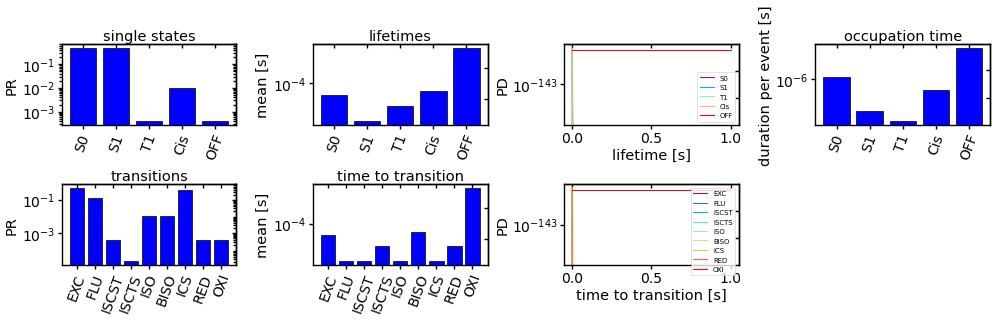

In [12]:
prediction.plot_all()

### Simulation

In [9]:
simulation = si.Simulation(transition_set)

In [10]:
simulation.run(size=int(1e2), end_time=None, seed=3)

### Analysis

In [11]:
analysis = st.Analysis(simulation)

array([[<AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>]], dtype=object)

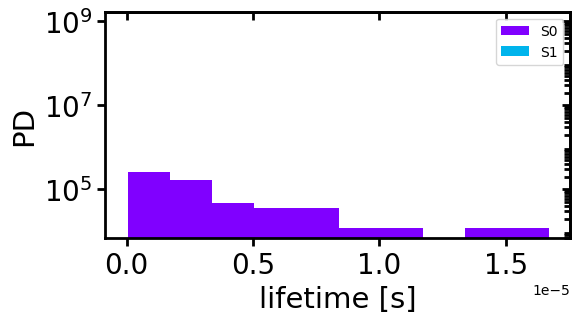

In [13]:
analysis.plot('lifetime_distributions')

array([[<AxesSubplot:title={'center':'single states'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'lifetimes'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>,
        <AxesSubplot:title={'center':'occupation time'}, ylabel='duration per event [s]'>],
       [<AxesSubplot:title={'center':'transitions'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'time to transition'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='time to transition [s]', ylabel='PD'>,
        <AxesSubplot:>]], dtype=object)

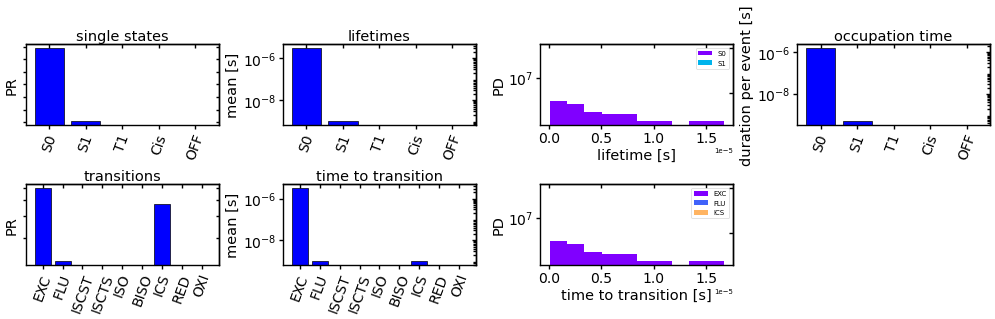

In [23]:
analysis.plot_all()

### Emissions

In [68]:
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='4ms', emccd_gain=10, seed=100)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

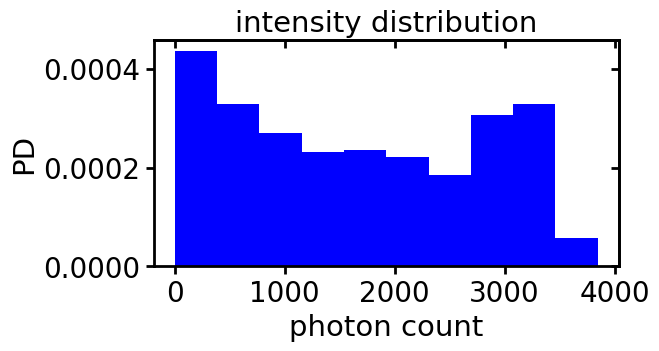

In [69]:
emissions.plot(mode='histogram')

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

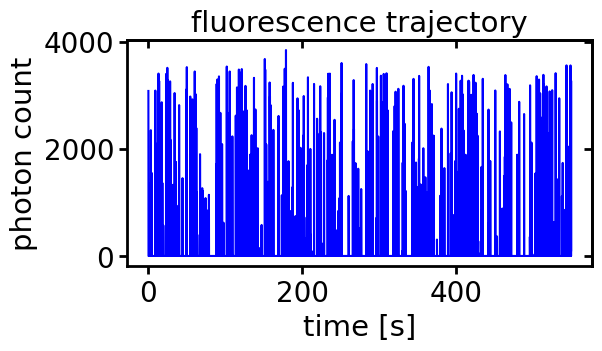

In [71]:
emissions.plot(mode='time_series')

### fcs

In [83]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-8, exp_max=2)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 5.00e-03$ s'}, xlabel='$\\tau [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

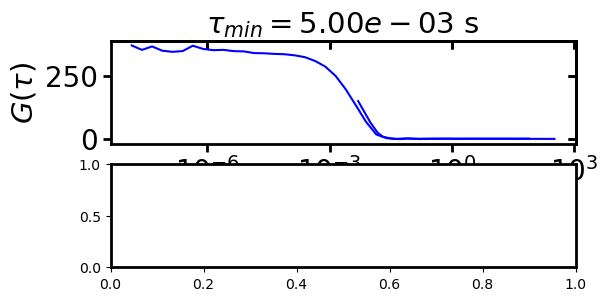

In [81]:
ax = fcs.plot(nrows=2)
fcs_2.plot(axes=ax[0])

### blinking

In [21]:
blinking = bl.Blinking(emissions)

array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

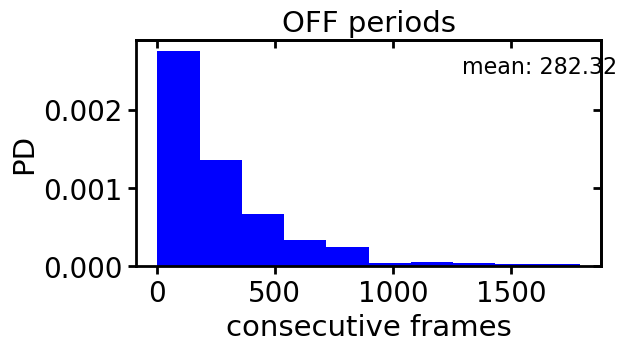

In [22]:
blinking.plot(mode='off_histogram')

### tcspc

In [9]:
tcspc = tc.TCSPC(transition_set)

In [10]:
tcspc.run(size=100000, seed=100)

In [11]:
tcspc.get_observed_lifetimes()

array([[<AxesSubplot:title={'center':'simulation'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

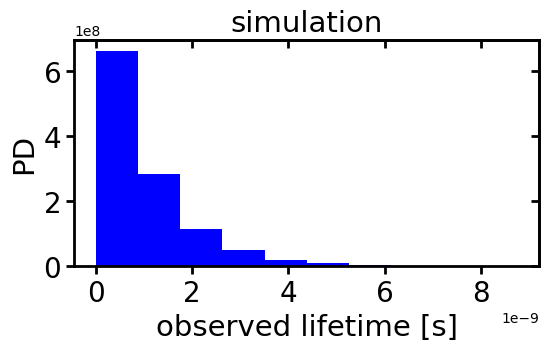

In [12]:
tcspc.plot()

In [17]:
tcspc.predict(accuracy=10, size=1000)

0.26999599438616656
1.0000000000000002


array([[<AxesSubplot:title={'center':'prediction'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

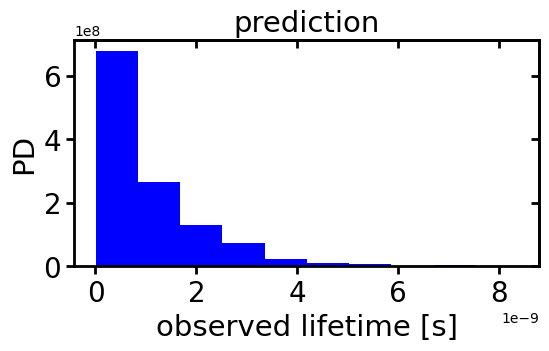

In [14]:
tcspc.plot('prediction')